In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [ ]:
stocks = [
    "ADANIENT.NS",
    "ADANIPORTS.NS",
    "APOLLOHOSP.NS",
    "ASIANPAINT.NS",
    "AXISBANK.NS",
    "BAJAJ-AUTO.NS",
    "BAJFINANCE.NS",
    "BEL.NS",
    "BHARTIARTL.NS",
    "CIPLA.NS",
    "COALINDIA.NS",
    "DRREDDY.NS",
    "EICHERMOT.NS",
    "ETERNAL.NS",   # formerly Zomato
    "GRASIM.NS",
    "HCLTECH.NS",
    "HDFCBANK.NS",
    "HDFCLIFE.NS",
    "HEROMOTOCO.NS",
    "HINDALCO.NS",
    "HINDUNILVR.NS",
    "ICICIBANK.NS",
    "INDUSINDBK.NS",
    "INFY.NS",
    "ITC.NS",
    "JIOFIN.NS",
    "JSWSTEEL.NS",
    "KOTAKBANK.NS",
    "LT.NS",
    "M&M.NS",
    "MARUTI.NS",
    "NESTLEIND.NS",
    "NTPC.NS",
    "ONGC.NS",
    "POWERGRID.NS",
    "RELIANCE.NS",
    "SBILIFE.NS",
    "SBIN.NS",
    "SHRIRAMFIN.NS",
    "SUNPHARMA.NS",
    "TATACONSUM.NS",
    "TATAMOTORS.NS",
    "TATASTEEL.NS",
    "TCS.NS",
    "TECHM.NS",
    "TITAN.NS",
    "TRENT.NS",
    "ULTRACEMCO.NS",
    "WIPRO.NS"
]


start = "2020-01-01"

In [ ]:
data = yf.download(
    stocks,
    start="2020-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

data.head()

$TATAMOTORS.NS: possibly delisted; no timezone found

1 Failed download:
['TATAMOTORS.NS']: possibly delisted; no timezone found


Ticker,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJFINANCE.NS,BEL.NS,BHARTIARTL.NS,CIPLA.NS,...,SUNPHARMA.NS,TATACONSUM.NS,TATAMOTORS.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,TRENT.NS,ULTRACEMCO.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-01,205.794510,361.062622,1403.106934,1705.415527,745.586853,2599.727539,413.532166,29.713718,433.316467,449.420258,...,406.073975,306.714386,NaN,38.457085,1841.149658,602.617493,1132.704834,526.402710,3942.765137,113.709183
2020-01-02,209.111359,366.321014,1470.294067,1702.990234,753.802612,2575.711670,414.973755,30.603798,435.132690,447.153809,...,406.681763,306.240784,NaN,39.862988,1832.697876,605.740906,1133.538452,538.031006,4117.159180,113.984627
2020-01-03,206.240051,365.699554,1461.883423,1665.661743,739.860840,2535.314453,409.833038,29.951078,435.037109,443.801361,...,415.704620,301.363342,NaN,39.768444,1869.222168,612.897034,1117.942017,532.614319,4092.328857,115.269981
2020-01-06,197.576584,363.500580,1438.667847,1623.577881,720.242737,2506.924316,390.604340,28.764307,429.827362,440.779388,...,411.356781,295.586121,NaN,38.909275,1869.052002,609.180603,1136.481323,526.700867,4032.095947,115.751999
2020-01-07,202.032059,367.898529,1454.603760,1639.983643,722.732300,2507.171631,391.674469,28.586294,425.477966,442.526459,...,417.387634,298.237915,NaN,39.143597,1873.638306,614.478333,1137.805420,529.682434,4114.540039,117.152138


In [ ]:
returns = data.pct_change()

momentum = data.pct_change(63)

don_high = (
    data
    .rolling(55)
    .max()
    .shift(1)
)

In [ ]:
rebalance_dates = momentum.index[63::21]

print("Rebalances:", len(rebalance_dates))

Rebalances: 74


In [ ]:
portfolio_returns = []

for i in range(len(rebalance_dates)-1):

    current_date = rebalance_dates[i]
    next_date = rebalance_dates[i+1]

    mom = momentum.loc[current_date]

    breakout = (
        data.loc[current_date]
        >
        don_high.loc[current_date]
    )

    candidates = mom[
        breakout.fillna(False)
    ].dropna()

    if len(candidates) == 0:
        continue

    ranked = candidates.sort_values(
        ascending=False
    )

    top5 = ranked.index[:5]

    period_returns = (
        returns.loc[
            current_date:next_date,
            top5
        ]
        .iloc[1:]
        .mean(axis=1)
    )

    portfolio_returns.append(
        period_returns
    )

portfolio_returns = pd.concat(
    portfolio_returns
)

In [ ]:
portfolio_curve = (
    1 + portfolio_returns
).cumprod()

benchmark_returns = (
    returns.mean(axis=1)
)

benchmark_curve = (
    1 + benchmark_returns
).cumprod()



In [ ]:

print(
    "Strategy Return:",
    round(
        (portfolio_curve.iloc[-1]-1)*100,
        2
    ),
    "%"
)

print(
    "Benchmark Return:",
    round(
        (benchmark_curve.iloc[-1]-1)*100,
        2
    ),
    "%"
)

sharpe = (
    portfolio_returns.mean()
    /
    portfolio_returns.std()
) * np.sqrt(252)

print(
    "Sharpe:",
    round(sharpe,2)
)

running_max = portfolio_curve.cummax()

drawdown = (
    portfolio_curve
    /
    running_max
    - 1
)

print(
    "Max Drawdown:",
    round(drawdown.min()*100,2),
    "%"
)

cagr = portfolio_curve.iloc[-1] ** (252/len(portfolio_curve)) - 1

print("CAGR:", round(cagr*100,2), "%")

Strategy Return: 231.47 %
Benchmark Return: 261.29 %
Sharpe: 1.09
Max Drawdown: -25.98 %
CAGR: 24.34 %


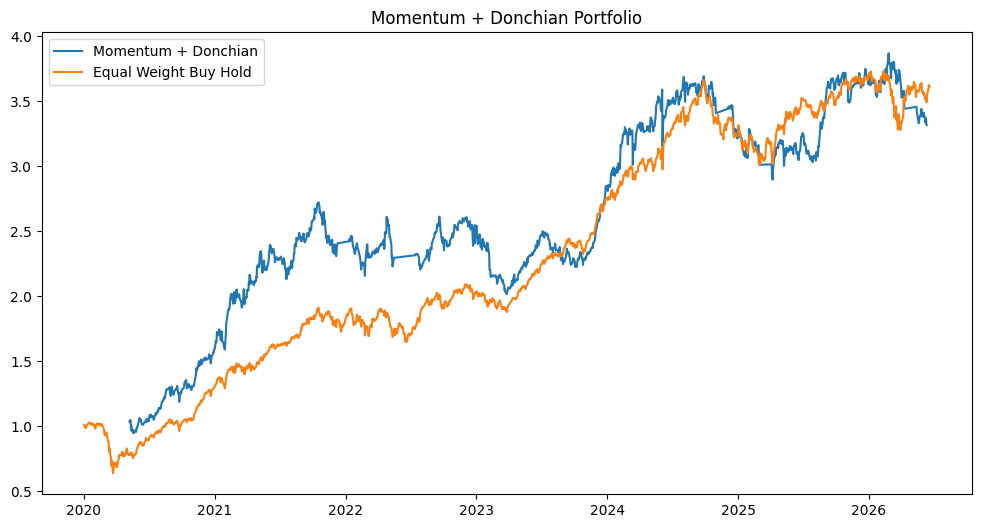

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    portfolio_curve,
    label="Momentum + Donchian"
)

plt.plot(
    benchmark_curve,
    label="Equal Weight Buy Hold"
)

plt.legend()

plt.title(
    "Momentum + Donchian Portfolio"
)

plt.show()